# Telco Customer Churn Data Analysis

In [1]:
#import labraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
telco=pd.read_csv("telco.csv")
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
#Fixing Incorrect Data Types & Missing Values

telco["TotalCharges"]=telco["TotalCharges"].str.strip()
telco["TotalCharges"]=pd.to_numeric(telco["TotalCharges"],errors="coerce")
telco["TotalCharges"]=telco["TotalCharges"].fillna(0)

In [6]:
telco.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [7]:
#convert SeniorCitizen(0/1) to (yes/no)

telco["SeniorCitizen"]=telco["SeniorCitizen"].map({0:"No",1:"Yes"})

In [8]:
#finding duplicate

duplicate_count=telco.duplicated().sum()
duplicate_count

np.int64(0)

## EDA(Exploratory Data Analysis)

### 1. What is the overall Churn Rate, and what is the company's current Revenue Loss Risk?

C:\Users\User\AppData\Local\Temp\ipykernel_7708\1017741507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=churn_count.index,y=churn_count.values,palette=colors)


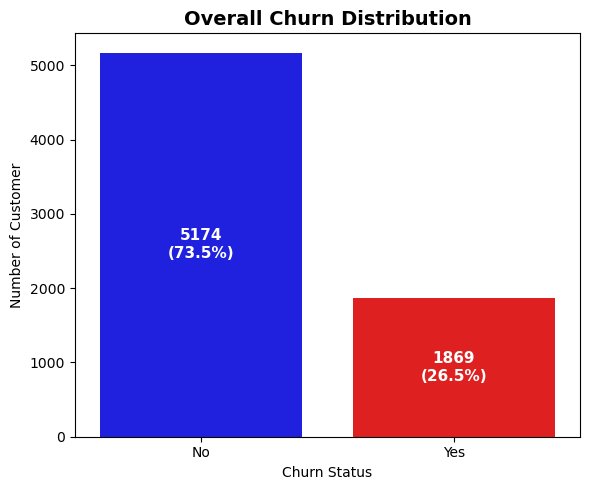

In [9]:
plt.figure(figsize=(6,5))
churn_count=telco["Churn"].value_counts()
colors=["blue","red"]

ax=sns.barplot(x=churn_count.index,y=churn_count.values,palette=colors)
plt.title("Overall Churn Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customer")

total = len(telco)
for p in ax.patches:
    percentage = f'{(100 * p.get_height() / total):.1f}%'
    ax.annotate(f'{int(p.get_height())}\n({percentage})',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontsize=11, fontweight='bold')
               

    
plt.tight_layout()
plt.show()


In [10]:

# Revenue Loss Calculation

churned_revenue = telco[telco['Churn'] == 'Yes']['MonthlyCharges'].sum()
total_revenue = telco['MonthlyCharges'].sum()
print(f"Monthly Revenue Lost to Churn: ${churned_revenue:,.2f} ({churned_revenue/total_revenue*100:.2f}% of Total Monthly Revenue)")

Monthly Revenue Lost to Churn: $139,130.85 (30.50% of Total Monthly Revenue)


### 2. Which customer profiles/segments have the highest risk of churn?

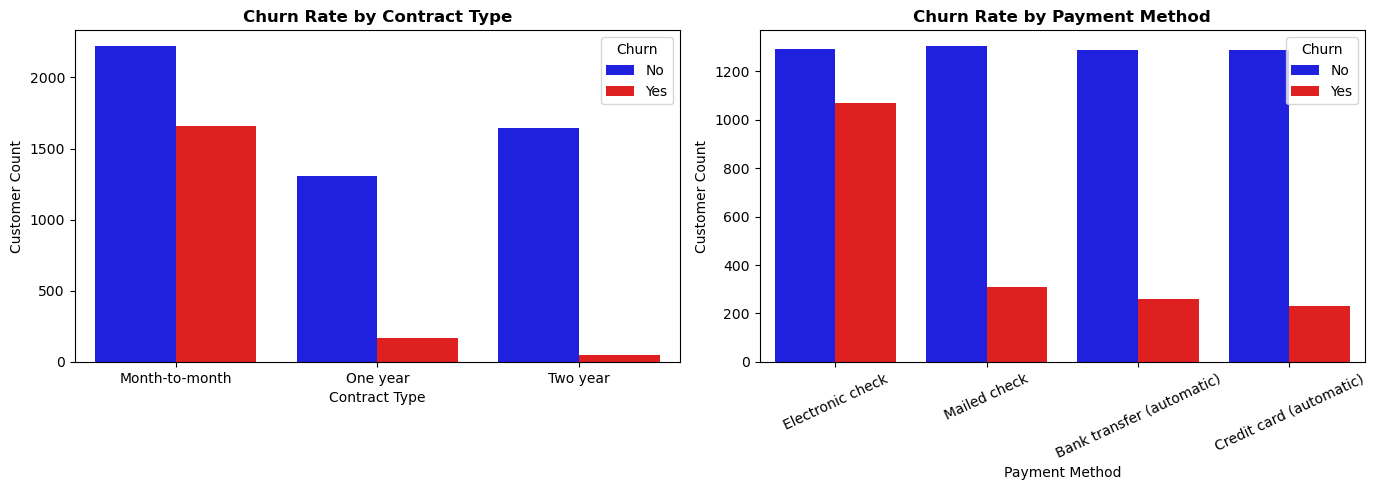

In [11]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
colors=["blue","red"]
#Contract Type vs Churn
sns.countplot(data=telco,x="Contract",hue="Churn",ax=axes[0],palette=colors)
axes[0].set_title("Churn Rate by Contract Type",fontsize=12, fontweight='bold')
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Customer Count")


#Payment method vs Churn
sns.countplot(data=telco,x="PaymentMethod",hue="Churn",ax=axes[1],palette=colors)
axes[1].set_title("Churn Rate by Payment Method",fontsize=12, fontweight='bold')
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Customer Count")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
                      

### 3. How do Monthly Charges and Tenure impact customer churn?

C:\Users\User\AppData\Local\Temp\ipykernel_7708\4248981350.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=telco,x="Churn", y="tenure",ax=axes[1],palette=colors)


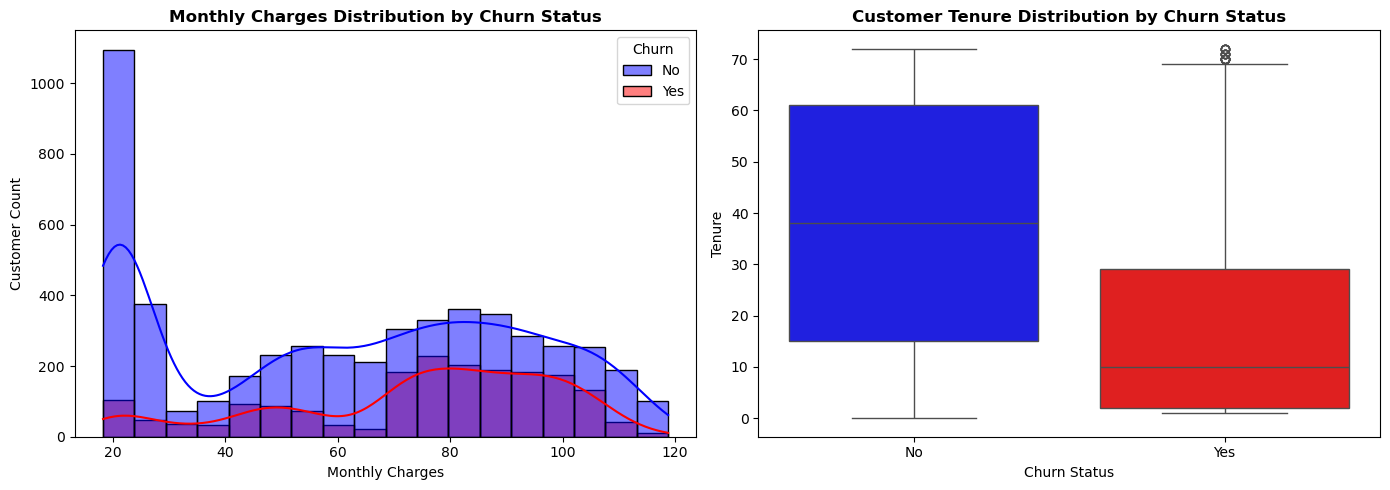

In [12]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
colors=["blue","red"]

#Monthly Charges Distribution by Churn

sns.histplot(data=telco,x="MonthlyCharges",kde=True,hue="Churn",ax=axes[0],palette=colors)
axes[0].set_title("Monthly Charges Distribution by Churn Status",fontweight="bold",fontsize=12)
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Customer Count")

#Tenure vs Churn Status
sns.boxplot(data=telco,x="Churn", y="tenure",ax=axes[1],palette=colors)
axes[1].set_title("Customer Tenure Distribution by Churn Status",fontweight="bold",fontsize=12)
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Tenure")

plt.tight_layout()
plt.show()

### 4. Internet Service & Add-on Services Impact

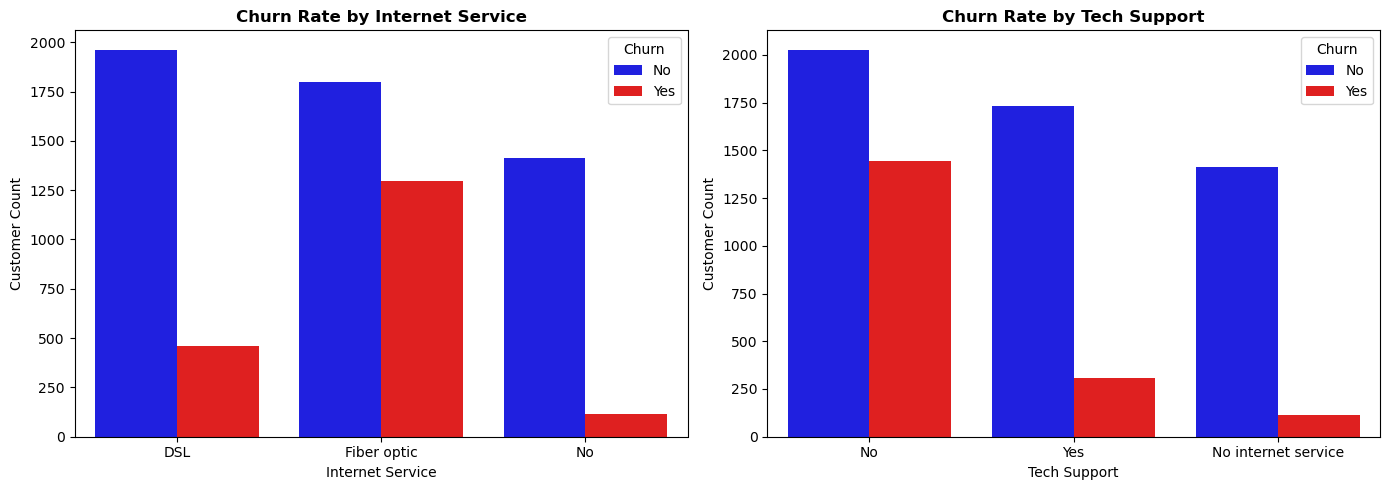

In [13]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
colors=["blue","red"]
#InternetService vs Churn
sns.countplot(data=telco,x="InternetService",hue="Churn",ax=axes[0],palette=colors)
axes[0].set_title("Churn Rate by Internet Service",fontsize=12, fontweight='bold')
axes[0].set_xlabel("Internet Service")
axes[0].set_ylabel("Customer Count")


#TechSupport vs Churn
sns.countplot(data=telco,x="TechSupport",hue="Churn",ax=axes[1],palette=colors)
axes[1].set_title("Churn Rate by Tech Support",fontsize=12, fontweight='bold')
axes[1].set_xlabel("Tech Support")
axes[1].set_ylabel("Customer Count")

plt.tight_layout()
plt.show()